### piecewise-linear approximation
https://www.researchgate.net/publication/282956677_Models_and_Algorithms_for_Optimal_Piecewise-Linear_Function_Approximation

In [2]:
data = [
    (0.0114, 0.1857),
    (0.0861, 0.4502),
    (0.1721, 0.5584),
    (0.2928, 0.5857),
    (0.3130, 0.7020),
    (0.3212, 0.8338),
    (0.4899, 0.8713),
    (0.8807, 0.9104)
]

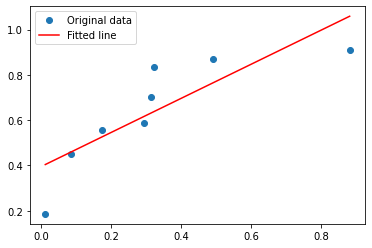

0.1268335478897872


In [4]:
import numpy as np
from matplotlib import pyplot as plt

def best_fit_line(x, y):
    w = np.ones_like(x)
    a = np.vstack([x, np.ones_like(x)])
    coefs = np.linalg.lstsq(a.T * w[:, np.newaxis], y * w, rcond=None)[0]
    return coefs

x = np.array([d[0] for d in data])
y = np.array([d[1] for d in data])
m, c = best_fit_line(x, y)
plt.plot(x, y, 'o', label="Original data")
plt.plot(x, m*x + c, 'r' , label="Fitted line")
plt.legend()
plt.show()
print(np.sum(np.power(y - m*x - c, 2)))

In [10]:
best_fit_error_for_range_one_segment = np.full((len(data), len(data)), np.inf)
for i in range(len(data)):
    for j in range(i+1, len(data)):
        x_partial = x[i:j+1]
        y_partial = y[i:j+1]
        m, c = best_fit_line(x_partial, y_partial)
        best_fit_error_for_range_one_segment[i, j] = np.sum(np.power(y_partial - m*x_partial - c, 2))
print(best_fit_error_for_range_one_segment)

[[           inf 5.70075264e-32 5.54234981e-03 2.26078436e-02
  2.30146033e-02 3.50310258e-02 4.40821571e-02 1.26833548e-01]
 [           inf            inf 4.00593428e-32 1.77379438e-03
  5.56153765e-03 2.32635486e-02 2.46214254e-02 5.77776464e-02]
 [           inf            inf            inf 0.00000000e+00
  5.22177128e-03 2.30990594e-02 2.44473597e-02 4.44621505e-02]
 [           inf            inf            inf            inf
  3.94430453e-31 2.27770680e-03 2.44459393e-02 3.61955443e-02]
 [           inf            inf            inf            inf
             inf 3.94430453e-30 8.03737889e-03 1.10883277e-02]
 [           inf            inf            inf            inf
             inf            inf 1.23259516e-32 1.31407347e-04]
 [           inf            inf            inf            inf
             inf            inf            inf 1.23259516e-32]
 [           inf            inf            inf            inf
             inf            inf            inf            inf]]

In [20]:
max_segments = 3

best_fit_error_for_range = np.full((len(data), max_segments), np.inf)
switch_point_index = np.zeros((len(data), max_segments))
for j in range(len(data)):
    best_fit_error_for_range[j, 0] = best_fit_error_for_range_one_segment[0, j]
    switch_point_index[j, 0] = 0
    for t in range(1, min(j, max_segments)):
        for i in range(t, j+1):
            best_with_one_fewer_segment = best_fit_error_for_range[i, t-1] + best_fit_error_for_range_one_segment[i, j]
            if best_fit_error_for_range[j, t] > best_with_one_fewer_segment:
                best_fit_error_for_range[j, t] = best_with_one_fewer_segment
                switch_point_index[j, t] = i

for j in range(best_fit_error_for_range.shape[0]):
    for t in range(best_fit_error_for_range.shape[1]):
        print(f"{best_fit_error_for_range[j, t]:10.6f}:{int(switch_point_index[j, t]):2d} ", end="")
    print()

       inf: 0        inf: 0        inf: 0 
  0.000000: 0        inf: 0        inf: 0 
  0.005542: 0   0.000000: 1        inf: 0 
  0.022608: 0   0.001774: 1   0.000000: 2 
  0.023015: 0   0.005562: 1   0.001774: 3 
  0.035031: 0   0.023015: 4   0.004052: 3 
  0.044082: 0   0.024621: 1   0.013599: 4 
  0.126834: 0   0.034103: 4   0.016650: 4 
